In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML



In [9]:
# 1. Variables and Constants
H = 500       
g = 9.81      
v_0 = 0       
dt = 0.1      
t_max = 10    

In [10]:
# 2. Euler's Method Function
def euler_free_fall(x0, v0, g, dt, t_max):
    t = np.arange(0, t_max, dt)
    x = np.zeros(len(t))
    v = np.zeros(len(t))
    x[0] = x0
    v[0] = v0
    
    for i in range(1, len(t)):
        v[i] = v[i-1] + g * dt
        x[i] = x[i-1] + v[i-1] * dt
        
    return t, x, v

t_euler, x_euler, v_euler = euler_free_fall(0, v_0, g, dt, t_max)
y_euler = H - x_euler 

# 3. Analytical Solution
t_ana = t_euler 
x_ana = v_0 * t_ana + 0.5 * g * t_ana**2
y_ana = H - x_ana 



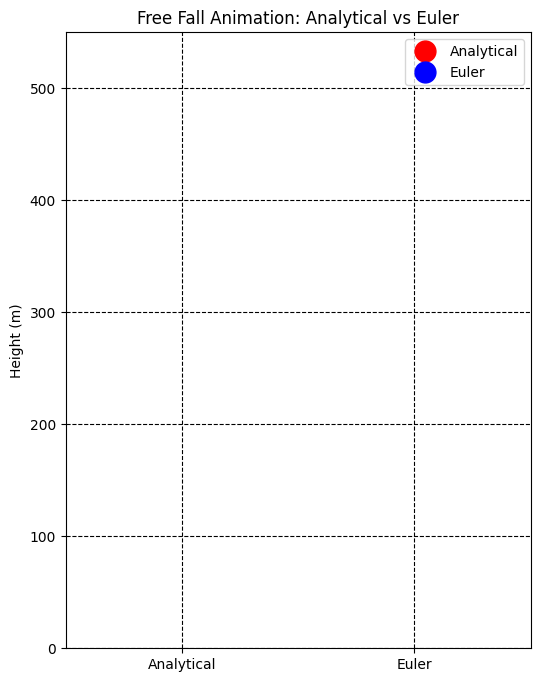

In [11]:
# 4. Figure and Axis Setup
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, H + 50)
ax.set_title('Free Fall Animation: Analytical vs Euler')
ax.set_ylabel('Height (m)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Analytical', 'Euler'])
ax.grid(True, color='black', linestyle='--', linewidth=0.8)

ball_ana, = ax.plot([], [], 'ro', markersize=15, label='Analytical')
ball_euler, = ax.plot([], [], 'bo', markersize=15, label='Euler')
time_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12)

ax.legend(loc="upper right")



In [12]:
# 5. Animation Functions
def init():
    ball_ana.set_data([], [])
    ball_euler.set_data([], [])
    time_text.set_text('')
    return ball_ana, ball_euler, time_text

def animate(i):
    ball_ana.set_data([0], [y_ana[i]])
    ball_euler.set_data([1], [y_euler[i]])
    time_text.set_text(f'Time: {t_ana[i]:.1f} s')
    return ball_ana, ball_euler, time_text

# 6. Animation Execution
ani = animation.FuncAnimation(
    fig, 
    animate, 
    frames=len(t_ana), 
    init_func=init, 
    blit=True, 
    interval=50 
)

In [13]:
plt.close(fig) 
HTML(ani.to_jshtml())